<img src="./logo_UNSAM.png" align="right" width="150" /> 

# Trabajo Semanal Nº2

#### Nicolás Galván

# Introducción

En este trabajo práctico se aborda el estudio del proceso de digitalización de señales mediante una simulación numérica implementada en Python. En lugar de analizar un convertidor analógico-digital (ADC) físico, se modela su comportamiento a partir de operaciones matemáticas que representan el muestreo, la adición de ruido y la cuantización de una señal.

La señal de interés es una senoidal de energía normalizada generada mediante una función propia, a la cual se le agrega ruido gaussiano aditivo para simular condiciones no ideales de adquisición. Este ruido se controla a través de un parámetro que permite ajustar su potencia en relación con el ruido de cuantización, posibilitando el análisis de distintos escenarios.

El proceso de cuantización se implementa de manera discreta utilizando una resolución finita determinada por la cantidad de bits y un rango dinámico definido. A partir de esto, se obtiene una señal digitalizada cuya diferencia con la señal original permite estudiar el error de cuantización y sus características estadísticas.

Asimismo, se analiza el comportamiento de las señales tanto en el dominio temporal como en el espectral, utilizando la Transformada Rápida de Fourier (FFT) para observar la distribución de potencia y la aparición de pisos de ruido. También se estudia la distribución del error de cuantización mediante histogramas, verificando su correspondencia con los modelos teóricos.

Finalmente, se evalúa la influencia de los parámetros principales del sistema, como la cantidad de bits y el nivel de ruido agregado, permitiendo comprender los compromisos entre resolución, ruido y calidad de la señal digital obtenida.

## Ejercicio Nº1

### Item a

Llamo a las librerías a utilizar y defino mis variables que voy a implementar.

In [169]:
import numpy as np
import matplotlib.pyplot as plt

N   = 1000
fs  = 1000
df  = fs / N
B   = 4
Vfs = 2
kn  = 1
f0 = df                 
A  = np.sqrt(2)   

Cálculo el paso de cuantización.

In [170]:
qq = Vfs / (2**B)   


Cálculo la potencia del ruido de cuantización.

In [171]:
Pq = qq**2 / 12

Defino mi función seno.

In [172]:
def mi_funcion_sen(vmax=1, dc=0, ff=1, ph=0, nn=1000, fs=1000):
    tt = np.arange(0, nn) / fs
    velang = 2 * np.pi * ff
    xx = dc + vmax * np.sin(velang * tt + ph)
    return tt, xx

Se llama a la función pasándole como parámetros la amplitud máxima de la señal senoidal, la frecuencia, el número de muestras tomadas por el ADC y la frecuencia de muestreo del ADC.

In [173]:
tt, ss = mi_funcion_sen(vmax=A, ff=f0, nn=N, fs=fs)

Defino la potencia del ruido analógico.

In [174]:
Pn  = kn * Pq

Defino mi señal que entra al ADC.

In [175]:
nn  = np.random.normal(0, np.sqrt(Pn), N)
sR  = ss + nn

Defino mi señal cuantizada y el error de cuantización.

In [176]:
sQ = np.round(sR / qq) * qq

eq = sQ - sR

Defino mis pisos de ruido.

In [177]:
piso_anal_dB = 10 * np.log10(Pn / (N/2))
piso_dig_dB  = 10 * np.log10(Pq / (N/2))

Defino mi función de espectro en dB.

In [178]:
def espectro_uni_dB(x, N):
    X   = np.fft.fft(x) / N
    P   = np.abs(X)**2
    Pu  = P[:N//2 + 1].copy()
    Pu[1:-1] *= 2
    return 10 * np.log10(Pu + 1e-20) # 1e-20 para evitar log10(0)

Defino mi eje de frecuencia.

In [179]:
frec = np.arange(N//2 + 1) * df

Cálculo espectros de:
- salida ADC
- señal original
- señal con ruido

In [180]:
dB_sQ = espectro_uni_dB(sQ, N)
dB_ss = espectro_uni_dB(ss, N)
dB_sR = espectro_uni_dB(sR, N)

Se grafica la señal cuantizada, la señal con ruido y la señal original.

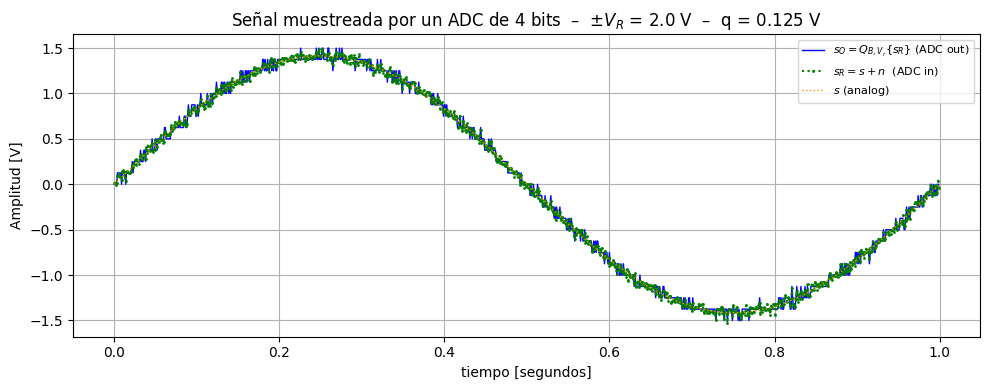

In [181]:
plt.figure(figsize=(10, 4))
plt.plot(tt, sQ,  color='blue',  lw=1,   label=r'$s_O = Q_{B,V_r}\{s_R\}$ (ADC out)')
plt.plot(tt, sR,  'g.',  ms=2, ls='dotted',   label=r'$s_R = s + n$  (ADC in)')
plt.plot(tt, ss,  color='darkorange', lw=1, ls='dotted', label=r'$s$ (analog)')
plt.xlabel('tiempo [segundos]')
plt.ylabel('Amplitud [V]')
plt.title(f'Señal muestreada por un ADC de {B} bits  –  'f'$\\pm V_R$ = {Vfs:.1f} V  –  q = {qq:.3f} V')
plt.legend(fontsize=8)
plt.grid(True)
plt.tight_layout()
plt.show()

Se grafica el espectro de la salida del ADC, el espectro de la señal original, el espectro de la señal con ruido, el piso de ruido analogico y el piso de ruido digital.

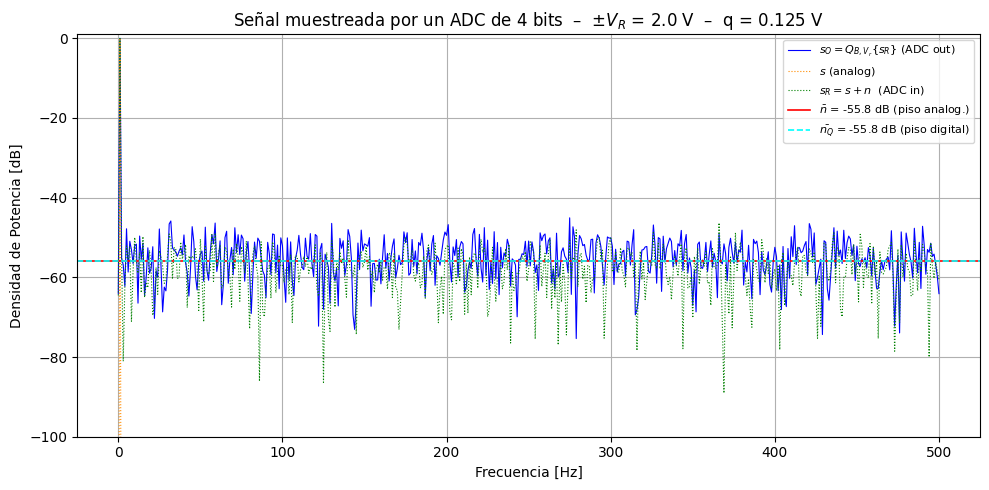

In [182]:
plt.figure(figsize=(10, 5))
plt.ylim(bottom=-100)
plt.plot(frec, dB_sQ, color='blue',  lw=0.8,label=r'$s_O = Q_{B,V_r}\{s_R\}$ (ADC out)')
plt.plot(frec, dB_ss, color='darkorange',  lw=0.8, ls='dotted', label=r'$s$ (analog)')
plt.plot(frec, dB_sR, color='green',      lw=0.8, ls='dotted', label=r'$s_R = s + n$  (ADC in)')

# Líneas horizontales de los pisos
plt.axhline(piso_anal_dB, color='red',  lw=1.2, ls='-', label=rf'$\bar{{n}}$ = {piso_anal_dB:.1f} dB (piso analog.)')
plt.axhline(piso_dig_dB,  color='cyan', lw=1.2, ls='--', label=rf'$\bar{{n_Q}}$ = {piso_dig_dB:.1f} dB (piso digital)')

plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Densidad de Potencia [dB]')
plt.title(f'Señal muestreada por un ADC de {B} bits  –  'f'$\\pm V_R$ = {Vfs:.1f} V  –  q = {qq:.3f} V')
plt.legend(fontsize=8)
plt.grid(True)
plt.tight_layout()
plt.show()

Se grafica el histograma del error de cuantización.

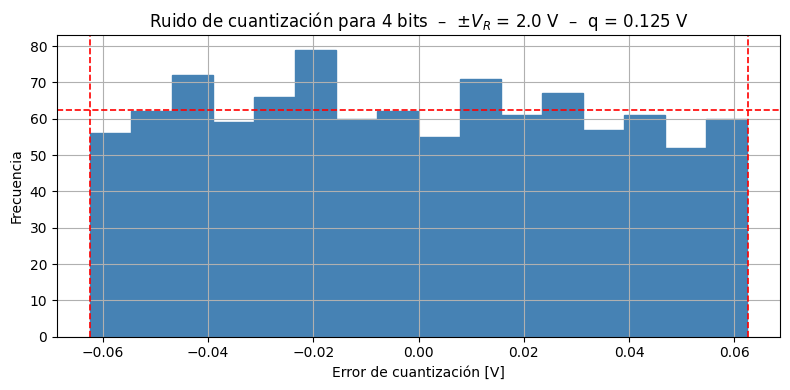

In [183]:
plt.figure(figsize=(8, 4))
plt.hist(eq, bins=16, color='steelblue', edgecolor='steelblue')

techo = N / 16         
x_izq = -qq / 2
x_der =  qq / 2

plt.axhline(techo, color='red', lw=1.2, ls='--')  
plt.axvline(x_izq, color='red', lw=1.2, ls='--')   
plt.axvline(x_der, color='red', lw=1.2, ls='--')    


plt.xlabel('Error de cuantización [V]')
plt.ylabel('Frecuencia')
plt.title(f'Ruido de cuantización para {B} bits  –  'f'$\\pm V_R$ = {Vfs:.1f} V  –  q = {qq:.3f} V')
plt.grid(True)
plt.tight_layout()
plt.show()


### Item b

##### Se realizó un nuevo análisis, pero con la siguiente configuración (16 bits) y usando diferentes Kn.

In [184]:
B   = 16
kn  = 10

Recalculó el paso de cuantización.

In [185]:
qq = Vfs / (2**B)   

Recalculó la potencia del ruido de cuantización.

In [186]:
Pq = qq**2 / 12

Recalculó la potencia del ruido analógico.

In [187]:
Pn  = kn * Pq

Se realiza un nuevo análisis mi señal que entra al ADC.

In [188]:
nn  = np.random.normal(0, np.sqrt(Pn), N)
sR  = ss + nn

Se redefinen la señal cuantizada y el error de cuantización.

In [189]:
sQ = np.round(sR / qq) * qq

eq = sQ - sR

Se redefinen los pisos de ruido.

In [190]:
piso_anal_dB = 10 * np.log10(Pn / (N/2))
piso_dig_dB  = 10 * np.log10(Pq / (N/2))

Recalculó espectros de:
- salida ADC
- señal original
- señal con ruido

In [191]:
dB_sQ = espectro_uni_dB(sQ, N)
dB_ss = espectro_uni_dB(ss, N)
dB_sR = espectro_uni_dB(sR, N)

Se grafica la nueva señal cuantizada, la nueva señal con ruido y la señal original.

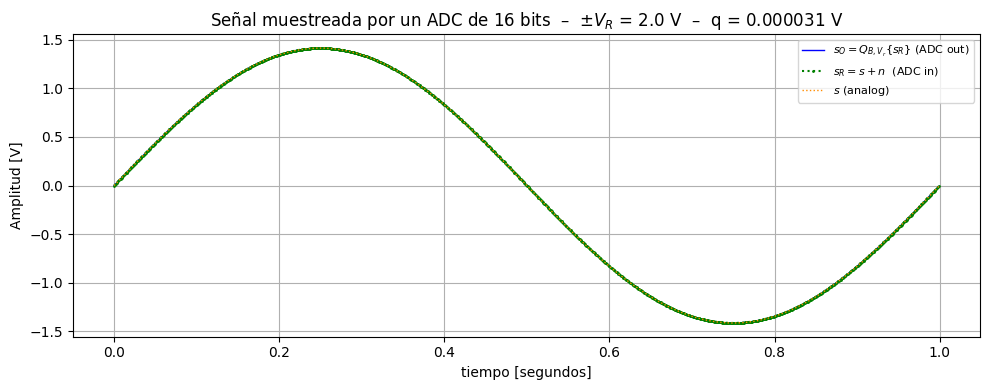

In [192]:
plt.figure(figsize=(10, 4))
plt.plot(tt, sQ,  color='blue',  lw=1,   label=r'$s_O = Q_{B,V_r}\{s_R\}$ (ADC out)')
plt.plot(tt, sR,  'g.',  ms=2, ls='dotted',   label=r'$s_R = s + n$  (ADC in)')
plt.plot(tt, ss,  color='darkorange', lw=1, ls='dotted', label=r'$s$ (analog)')
plt.xlabel('tiempo [segundos]')
plt.ylabel('Amplitud [V]')
plt.title(f'Señal muestreada por un ADC de {B} bits  –  'f'$\\pm V_R$ = {Vfs:.1f} V  –  q = {qq:.6f} V')
plt.legend(fontsize=8)
plt.grid(True)
plt.tight_layout()
plt.show()

Se generan nuevamente las gráficas del espectro de la salida del ADC, el espectro de la señal original, el espectro de la señal con ruido, el piso de ruido analogico y el piso de ruido digital.

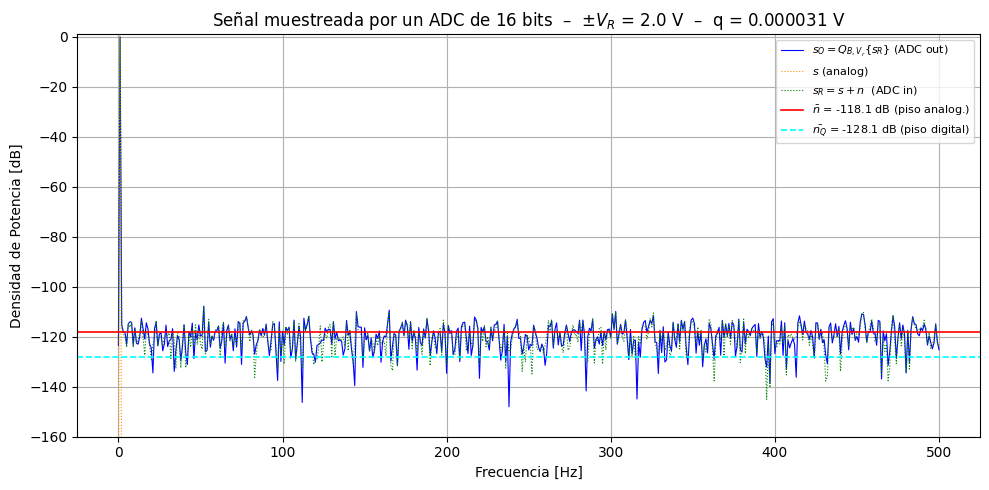

In [193]:
plt.figure(figsize=(10, 5))
plt.ylim(bottom=-160)
plt.plot(frec, dB_sQ, color='blue',  lw=0.8,label=r'$s_O = Q_{B,V_r}\{s_R\}$ (ADC out)')
plt.plot(frec, dB_ss, color='darkorange',  lw=0.8, ls='dotted', label=r'$s$ (analog)')
plt.plot(frec, dB_sR, color='green',      lw=0.8, ls='dotted', label=r'$s_R = s + n$  (ADC in)')

# Líneas horizontales de los pisos
plt.axhline(piso_anal_dB, color='red',  lw=1.2, ls='-', label=rf'$\bar{{n}}$ = {piso_anal_dB:.1f} dB (piso analog.)')
plt.axhline(piso_dig_dB,  color='cyan', lw=1.2, ls='--', label=rf'$\bar{{n_Q}}$ = {piso_dig_dB:.1f} dB (piso digital)')

plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Densidad de Potencia [dB]')
plt.title(f'Señal muestreada por un ADC de {B} bits  –  'f'$\\pm V_R$ = {Vfs:.1f} V  –  q = {qq:.6f} V')
plt.legend(fontsize=8)
plt.grid(True)
plt.tight_layout()
plt.show()

Se vuelve a graficar el histograma del error de cuantización.

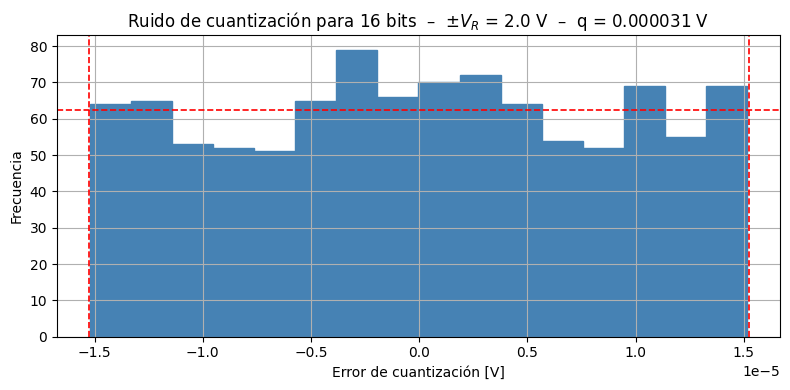

In [194]:
plt.figure(figsize=(8, 4))
plt.hist(eq, bins=16, color='steelblue', edgecolor='steelblue')

techo = N / 16          
x_izq = -qq / 2
x_der =  qq / 2

plt.axhline(techo, color='red', lw=1.2, ls='--')   
plt.axvline(x_izq, color='red', lw=1.2, ls='--')   
plt.axvline(x_der, color='red', lw=1.2, ls='--')   


plt.xlabel('Error de cuantización [V]')
plt.ylabel('Frecuencia')
plt.title(f'Ruido de cuantización para {B} bits  –  'f'$\\pm V_R$ = {Vfs:.1f} V  –  q = {qq:.6f} V')
plt.grid(True)
plt.tight_layout()
plt.show()

##### Mismo procedimiento, pero Kn=1/10

In [195]:
kn  = 1/10
Pn  = kn * Pq
nn  = np.random.normal(0, np.sqrt(Pn), N)
sR  = ss + nn
sQ = np.round(sR / qq) * qq
eq = sQ - sR
piso_anal_dB = 10 * np.log10(Pn / (N/2))
piso_dig_dB  = 10 * np.log10(Pq / (N/2))
dB_sQ = espectro_uni_dB(sQ, N)
dB_ss = espectro_uni_dB(ss, N)
dB_sR = espectro_uni_dB(sR, N)

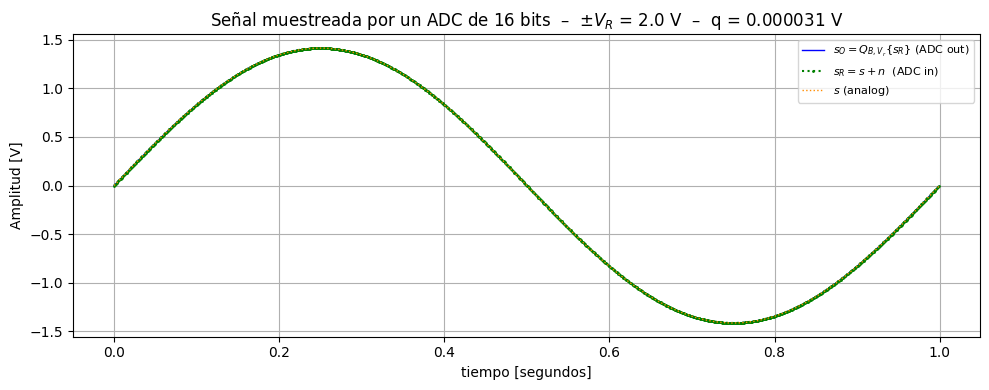

In [196]:
plt.figure(figsize=(10, 4))
plt.plot(tt, sQ,  color='blue',  lw=1,   label=r'$s_O = Q_{B,V_r}\{s_R\}$ (ADC out)')
plt.plot(tt, sR,  'g.',  ms=2, ls='dotted',   label=r'$s_R = s + n$  (ADC in)')
plt.plot(tt, ss,  color='darkorange', lw=1, ls='dotted', label=r'$s$ (analog)')
plt.xlabel('tiempo [segundos]')
plt.ylabel('Amplitud [V]')
plt.title(f'Señal muestreada por un ADC de {B} bits  –  'f'$\\pm V_R$ = {Vfs:.1f} V  –  q = {qq:.6f} V')
plt.legend(fontsize=8)
plt.grid(True)
plt.tight_layout()
plt.show()

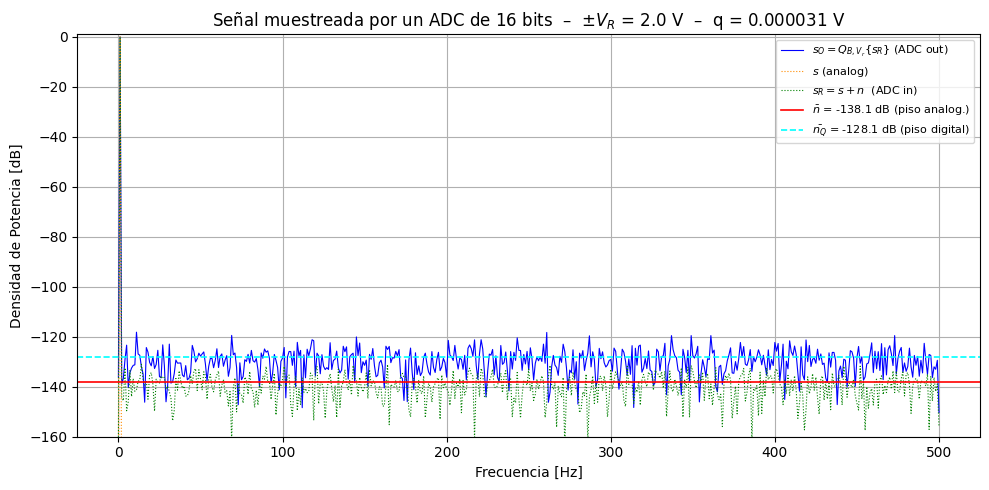

In [197]:
plt.figure(figsize=(10, 5))
plt.ylim(bottom=-160)
plt.plot(frec, dB_sQ, color='blue',  lw=0.8,label=r'$s_O = Q_{B,V_r}\{s_R\}$ (ADC out)')
plt.plot(frec, dB_ss, color='darkorange',  lw=0.8, ls='dotted', label=r'$s$ (analog)')
plt.plot(frec, dB_sR, color='green',      lw=0.8, ls='dotted', label=r'$s_R = s + n$  (ADC in)')

# Líneas horizontales de los pisos
plt.axhline(piso_anal_dB, color='red',  lw=1.2, ls='-', label=rf'$\bar{{n}}$ = {piso_anal_dB:.1f} dB (piso analog.)')
plt.axhline(piso_dig_dB,  color='cyan', lw=1.2, ls='--', label=rf'$\bar{{n_Q}}$ = {piso_dig_dB:.1f} dB (piso digital)')

plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Densidad de Potencia [dB]')
plt.title(f'Señal muestreada por un ADC de {B} bits  –  'f'$\\pm V_R$ = {Vfs:.1f} V  –  q = {qq:.6f} V')
plt.legend(fontsize=8)
plt.grid(True)
plt.tight_layout()
plt.show()

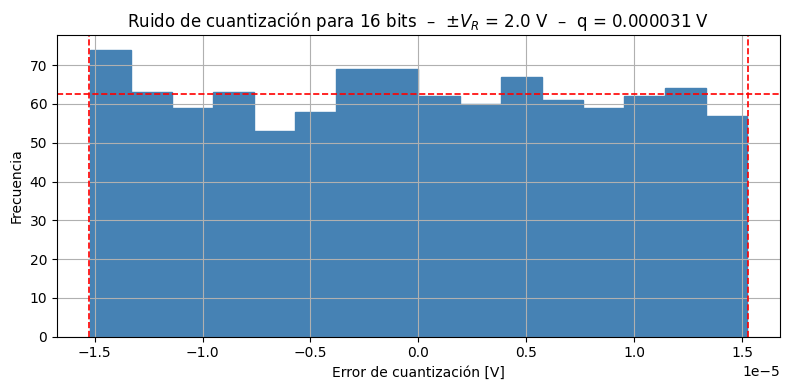

In [198]:
plt.figure(figsize=(8, 4))
plt.hist(eq, bins=16, color='steelblue', edgecolor='steelblue')

techo = N / 16          
x_izq = -qq / 2
x_der =  qq / 2

plt.axhline(techo, color='red', lw=1.2, ls='--')   
plt.axvline(x_izq, color='red', lw=1.2, ls='--')   
plt.axvline(x_der, color='red', lw=1.2, ls='--')   


plt.xlabel('Error de cuantización [V]')
plt.ylabel('Frecuencia')
plt.title(f'Ruido de cuantización para {B} bits  –  'f'$\\pm V_R$ = {Vfs:.1f} V  –  q = {qq:.6f} V')
plt.grid(True)
plt.tight_layout()
plt.show()

##### Mismo procedimiento, pero Kn=1

In [199]:
kn  = 1
Pn  = kn * Pq
nn  = np.random.normal(0, np.sqrt(Pn), N)
sR  = ss + nn
sQ = np.round(sR / qq) * qq
eq = sQ - sR
piso_anal_dB = 10 * np.log10(Pn / (N/2))
piso_dig_dB  = 10 * np.log10(Pq / (N/2))
dB_sQ = espectro_uni_dB(sQ, N)
dB_ss = espectro_uni_dB(ss, N)
dB_sR = espectro_uni_dB(sR, N)

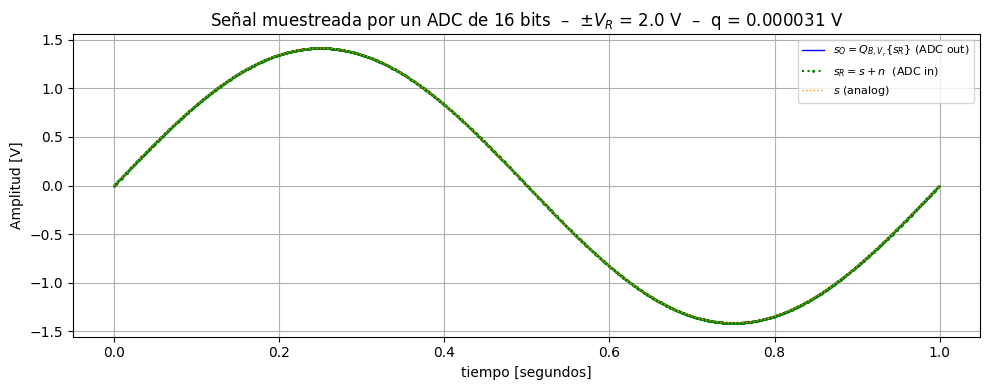

In [200]:
plt.figure(figsize=(10, 4))
plt.plot(tt, sQ,  color='blue',  lw=1,   label=r'$s_O = Q_{B,V_r}\{s_R\}$ (ADC out)')
plt.plot(tt, sR,  'g.',  ms=2, ls='dotted',   label=r'$s_R = s + n$  (ADC in)')
plt.plot(tt, ss,  color='darkorange', lw=1, ls='dotted', label=r'$s$ (analog)')
plt.xlabel('tiempo [segundos]')
plt.ylabel('Amplitud [V]')
plt.title(f'Señal muestreada por un ADC de {B} bits  –  'f'$\\pm V_R$ = {Vfs:.1f} V  –  q = {qq:.6f} V')
plt.legend(fontsize=8)
plt.grid(True)
plt.tight_layout()
plt.show()

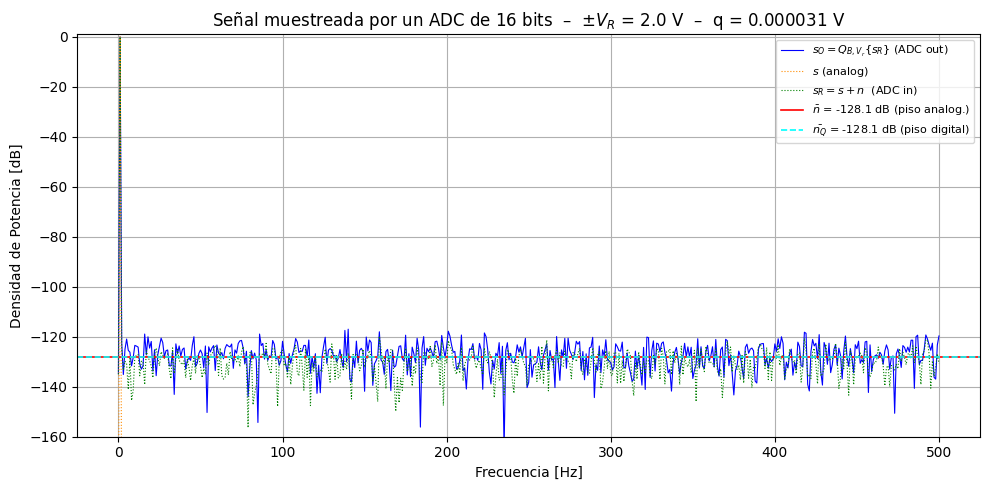

In [201]:
plt.figure(figsize=(10, 5))
plt.ylim(bottom=-160)
plt.plot(frec, dB_sQ, color='blue',  lw=0.8,label=r'$s_O = Q_{B,V_r}\{s_R\}$ (ADC out)')
plt.plot(frec, dB_ss, color='darkorange',  lw=0.8, ls='dotted', label=r'$s$ (analog)')
plt.plot(frec, dB_sR, color='green',      lw=0.8, ls='dotted', label=r'$s_R = s + n$  (ADC in)')

# Líneas horizontales de los pisos
plt.axhline(piso_anal_dB, color='red',  lw=1.2, ls='-', label=rf'$\bar{{n}}$ = {piso_anal_dB:.1f} dB (piso analog.)')
plt.axhline(piso_dig_dB,  color='cyan', lw=1.2, ls='--', label=rf'$\bar{{n_Q}}$ = {piso_dig_dB:.1f} dB (piso digital)')

plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Densidad de Potencia [dB]')
plt.title(f'Señal muestreada por un ADC de {B} bits  –  'f'$\\pm V_R$ = {Vfs:.1f} V  –  q = {qq:.6f} V')
plt.legend(fontsize=8)
plt.grid(True)
plt.tight_layout()
plt.show()

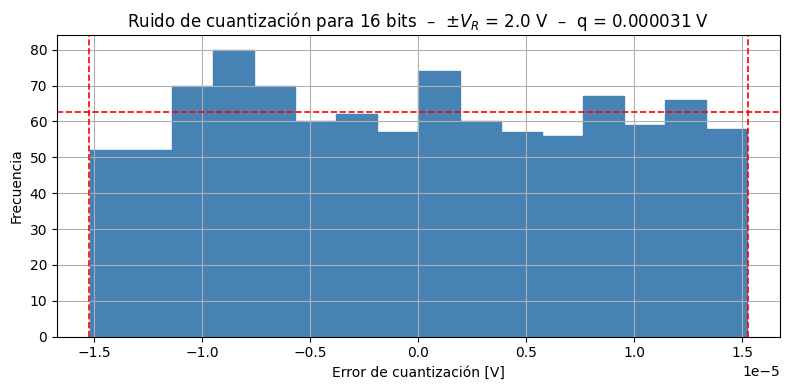

In [272]:
plt.figure(figsize=(8, 4))
plt.hist(eq, bins=16, color='steelblue', edgecolor='steelblue')

techo = N / 16          
x_izq = -qq / 2
x_der =  qq / 2

plt.axhline(techo, color='red', lw=1.2, ls='--')   
plt.axvline(x_izq, color='red', lw=1.2, ls='--')   
plt.axvline(x_der, color='red', lw=1.2, ls='--')   


plt.xlabel('Error de cuantización [V]')
plt.ylabel('Frecuencia')
plt.title(f'Ruido de cuantización para {B} bits  –  'f'$\\pm V_R$ = {Vfs:.1f} V  –  q = {qq:.6f} V')
plt.grid(True)
plt.tight_layout()
plt.show()

# Análisis de Resultados
## Temporal
Se comparan los resultados obtenidos para dos configuraciones del sistema: por un lado, B = 4 bits y $k_n$ = 1 (apartado a)), y por otro, B = 16 bits y $k_n$ = {1/10,1,10}.

Para el caso de B = 4 y $k_n$ = 1, la señal de salida del ADC presenta una degradación moderada. Esto se debe a que el ruido de cuantización es significativo (debido a la baja resolución) y, al mismo tiempo, el ruido analógico tiene una potencia comparable. En el dominio temporal se observa una señal escalonada con dispersión alrededor de la senoidal ideal.

**Comparación con configuraciones adicionales (B = 16):**

- Con $k_n$ = 10, el error de cuantización es prácticamente despreciable y la señal sigue de cerca a la entrada. Sin embargo, el ruido analógico domina la degradación.
- Con $k_n$ = 1, en comparación con el apartado a), desaparece prácticamente el efecto escalonado (cuantización), pero se mantiene una dispersión similar debido al ruido analógico. Es decir, se mejora la representación pero no completamente la calidad.
- Con $k_n$ = 1/10, respecto al caso a), la mejora es notable: se eliminan tanto los escalonamientos como gran parte de la dispersión, obteniéndose una señal mucho más cercana a la ideal. Aquí sí se evidencia claramente el beneficio de aumentar B.

En conjunto:
- Apartado a) (B = 4, $k_n$ = 1): cuantización y ruido influyen de forma similar.
- B = 16, $k_n$ = 1: mejora la cuantización, pero el ruido sigue limitando.
- B = 16, $k_n$ = 1/10: mejora global significativa.
- B = 16, $k_n$ = 10: domina el ruido analógico.

---

## Espectro

En el caso del apartado a) (B = 4, $k_n$ = 1), el espectro presenta un piso de ruido donde contribuyen tanto el ruido analógico como el de cuantización.

**Comparación con configuraciones adicionales (B = 16):**

- Con$k_n$ = 10, el piso de ruido está claramente dominado por el ruido analógico, mientras que el de cuantización es despreciable.
- Con $k_n$ = 1, respecto al apartado a), el piso de ruido disminuye levemente debido a la reducción del ruido de cuantización, aunque el ruido analógico sigue siendo relevante.
- Con $k_n$ = 1/10, en comparación con el apartado a), el piso de ruido es mucho menor. En este caso, la mejora en resolución sí se traduce en un espectro más limpio, ya que ambas fuentes de ruido son bajas.

En resumen:
- Apartado a): ambos ruidos afectan el espectro.
- B = 16, $k_n$ = 1: menor contribución de cuantización.
- B = 16, $k_n$ = 1/10: espectro significativamente más limpio.
- B = 16, $k_n$ = 10: espectro dominado por ruido analógico.

---

## Ruido de cuantización

En el apartado a) (B = 4, $k_n$ = 1), el error de cuantización tiene una amplitud considerable y afecta significativamente la señal.

**Comparación con configuraciones adicionales (B = 16):**

- Con $k_n$ = 10, el error de cuantización es extremadamente pequeño y su impacto es despreciable frente al ruido analógico.
- Con $k_n$ = 1, respecto al apartado a), la amplitud del error disminuye drásticamente, haciendo que su efecto sobre la señal sea mucho menor.
- Con $k_n$ = 1/10, comparado con el apartado a), el error de cuantización pasa a ser la principal fuente residual, aunque su magnitud es tan baja que su impacto práctico es mínimo.

En conclusión:
- Apartado a): el ruido de cuantización es relevante.
- B = 16, $k_n$ = 1: el error se reduce fuertemente.
- B = 16, $k_n$ = 1/10: el error es mínimo pero dominante respecto a otras fuentes pequeñas.
- B = 16, $k_n$ = 10: el error de cuantización es despreciable frente al ruido analógico.

# Bonus

## SNR en conversores ADC

El SNR en decibelios para un conversor de $N$ bits se expresa mediante la siguiente ecuación:

$$SNR = 6.02N + 10.79 + 20\log_{10}\left(\frac{\sigma_x}{V_{FS}}\right)$$

Esta fórmula muestra que el SNR depende de tres factores críticos:

- **La resolución ($N$):** Al aumentar el número de bits, se reduce el tamaño del
escalón de cuantización ($\Delta V$), lo que disminuye la potencia del ruido de
cuantización y aumenta el SNR.

- **El nivel de la señal ($\sigma_x$):** Representa el valor eficaz (rms) de la señal de
entrada. Cuanto mayor sea este nivel, mejor será el SNR.

- **El rango de escala completa ($V_{FS}$):** Es el rango total de voltaje que el ADC
puede manejar. Si la señal es pequeña comparada con este rango, el SNR
disminuye debido a que el término logarítmico se vuelve más negativo.

### Regla de oro

En el cálculo del SNR
para una **onda senoidal** que ocupa todo el rango del conversor. El resultado es la
conocida **"regla de oro"**:

$$SNR = 6.02N + 1.76 \text{ dB}$$

De esta fórmula podemos deducir que la resolución del conversor tiene un impacto lineal de aproximadamente 6 dB por bit en el SNR

### Autoevaluación del aprendisaje

A lo largo de este trabajo práctico se logró profundizar en la comprensión del proceso de digitalización de señales mediante un ADC, incorporando no solo el efecto de la cuantización sino también el impacto del muestreo y del ruido analógico aditivo. Se pudo verificar cómo una señal senoidal de energía normalizada se ve afectada por estos fenómenos, tanto en el dominio temporal como en el espectral.

En una primera instancia, se implementó el modelo completo del ADC con una configuración de referencia (B = 4 bits y $k_n$ = 1). Esto permitió observar claramente la presencia del ruido de cuantización, la discretización en amplitud de la señal y la aparición de pisos de ruido bien definidos en el espectro. Asimismo, el histograma del error de cuantización evidenció una distribución aproximadamente uniforme, en concordancia con el modelo teórico.

En una segunda etapa, se analizó el comportamiento del sistema al modificar los parámetros del ADC y del ruido analógico, considerando distintas configuraciones de resolución y niveles de ruido, en nuestro caso B = 16 bits y $k_n$ = {1/10,1,10}. Este análisis permitió extraer las siguientes conclusiones:

- Al aumentar la cantidad de bits, disminuye el paso de cuantización, reduciendo así la potencia del ruido de cuantización. Esto se traduce en una mejora significativa en la calidad de la señal digital y en una disminución del piso de ruido digital en el espectro.
- Para valores bajos de $k_n$ (menores a 1), el ruido analógico es despreciable frente al de cuantización, por lo que el desempeño del sistema está limitado principalmente por la resolución del ADC.
- Para valores altos de $k_n$ (mayores a 1), el ruido analógico domina, elevando el piso de ruido total y enmascarando los beneficios de aumentar la cantidad de bits.
- Existe un compromiso entre resolución y nivel de ruido: incrementar B más allá de cierto punto no produce mejoras apreciables si el ruido analógico es elevado.

En comparación con los resultados obtenidos en el apartado a), se pudo observar que dicha configuración representa un caso intermedio donde ambos tipos de ruido tienen contribuciones similares. Esto permitió utilizarla como referencia para evaluar cómo varía el sistema al modificar cada parámetro de manera independiente.

En conclusión, este trabajo permitió no solo implementar un modelo funcional de un ADC, sino también interpretar sus limitaciones prácticas y comprender la relación entre cuantización, ruido y calidad de la señal. En particular, el análisis del SNR permite cuantificar de manera directa estos efectos, evidenciando que la resolución del conversor tiene un impacto lineal en dB (aproximadamente 6 dB por bit), mientras que el nivel de la señal y su aprovechamiento del rango completo del ADC resultan igualmente determinantes. De este modo, se concluye que maximizar el SNR no depende únicamente de aumentar la cantidad de bits, sino de lograr un adecuado ajuste entre resolución, nivel de señal y rango dinámico, evitando tanto la subutilización del conversor como la dominancia del ruido analógico.